## 1. Import knižníc

In [1]:

import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from models.feature_extraction import FeatureExtractor
from models.utils import get_device
from utils.clustering import (
    reduce_dimensionality,
    cluster_features,
    visualize_clusters_2d,
    display_cluster_samples,
    compute_average_images,
    analyze_clusters,
)
from utils.evaluation import (
    plot_training_history,
    plot_residuals,
    plot_predictions_comparison,
)

print(f"Verzia PyTorch: {torch.__version__}")

try:
    import intel_extension_for_pytorch as ipex
    print(f"Intel Extension for PyTorch: {ipex.__version__}")
except (ImportError, OSError) as e:
    print(f"Intel Extension for PyTorch nie je dostupné: {e}")

if hasattr(torch, 'xpu') and torch.xpu.is_available():
    print(f"Intel XPU dostupné: {torch.xpu.device_count()} zariadení")
    for i in range(torch.xpu.device_count()):
        print(f"  [{i}]: {torch.xpu.get_device_name(i)}")
else:
    print("Používa sa CPU (GPU nebolo detekované)")

device = get_device()

Verzia PyTorch: 2.7.0+xpu
Intel Extension for PyTorch: 2.7.10+xpu
Intel XPU dostupné: 1 zariadení
  [0]: Intel(R) Arc(TM) B580 Graphics
Intel Arc GPU detected: Intel(R) Arc(TM) B580 Graphics
Intel XPU dostupné: 1 zariadení
  [0]: Intel(R) Arc(TM) B580 Graphics
Intel Arc GPU detected: Intel(R) Arc(TM) B580 Graphics


## 2. Načítanie spracovaných dát

In [2]:
data_dir = project_root / "dataset" / "Solar_data"
processed_dir = project_root / "dataset" / "processed"

train_df = pl.read_csv(processed_dir / "train.csv")
val_df = pl.read_csv(processed_dir / "val.csv")
test_df = pl.read_csv(processed_dir / "test.csv")

print(f"Trénovacie vzorky: {len(train_df)}")
print(f"Validačné vzorky: {len(val_df)}")
print(f"Testovacie vzorky: {len(test_df)}")

# Zobrazenie štatistík cieľovej premennej
print(f"\nŠtatistiky Irradiance:")
print(f"  Trénovacie - priemer: {train_df['Irradiance'].mean():.2f}, std: {train_df['Irradiance'].std():.2f}")
print(f"  Validačné  - priemer: {val_df['Irradiance'].mean():.2f}, std: {val_df['Irradiance'].std():.2f}")
print(f"  Testovacie - priemer: {test_df['Irradiance'].mean():.2f}, std: {test_df['Irradiance'].std():.2f}")

Trénovacie vzorky: 4204
Validačné vzorky: 901
Testovacie vzorky: 902

Štatistiky Irradiance:
  Trénovacie - priemer: 297.71, std: 281.30
  Validačné  - priemer: 299.44, std: 286.58
  Testovacie - priemer: 304.90, std: 284.23


## 3. Výber predtrénovaného modelu pre extrakciu príznakov

Vyberieme MobileNetV2 (menší počet parametrov = rýchlejšie výpočty)

In [3]:
model_name = "mobilenet_v2"

print(f"Vybraný model: {model_name}")
print("\nInicializácia Feature Extractor...")

feature_extractor = FeatureExtractor(model_name=model_name, device=device)

print(f"Model úspešne načítaný na zariadenie: {device}")
print(f"Veľkosť výstupného feature vektora: {feature_extractor.feature_dim}")

Vybraný model: mobilenet_v2

Inicializácia Feature Extractor...
Model úspešne načítaný na zariadenie: xpu
Veľkosť výstupného feature vektora: 1280
Model úspešne načítaný na zariadenie: xpu
Veľkosť výstupného feature vektora: 1280


## 4. Extrakcia príznakov z obrázkov

Použijeme predtrénovaný model na extrakciu príznakov zo všetkých obrázkov.

In [4]:
print("="*80)
print("EXTRAKCIA PRÍZNAKOV Z TRÉNOVACEJ MNOŽINY")
print("="*80)
train_features_df = feature_extractor.extract_features_from_dataframe(
    train_df, 
    data_dir,
    batch_size=64,
    use_resized=True
)

print("\n" + "="*80)
print("EXTRAKCIA PRÍZNAKOV Z VALIDAČNEJ MNOŽINY")
print("="*80)
val_features_df = feature_extractor.extract_features_from_dataframe(
    val_df,
    data_dir,
    batch_size=64,
    use_resized=True
)

print("\n" + "="*80)
print("EXTRAKCIA PRÍZNAKOV Z TESTOVACEJ MNOŽINY")
print("="*80)
test_features_df = feature_extractor.extract_features_from_dataframe(
    test_df,
    data_dir,
    batch_size=64,
    use_resized=True
)

print("\n" + "="*80)
print("EXTRAKCIA PRÍZNAKOV DOKONČENÁ")
print("="*80)
print(f"Trénovacie príznaky: {train_features_df.shape}")
print(f"Validačné príznaky: {val_features_df.shape}")
print(f"Testovacie príznaky: {test_features_df.shape}")

EXTRAKCIA PRÍZNAKOV Z TRÉNOVACEJ MNOŽINY


Extrakcia príznakov (mobilenet_v2): 100%|██████████| 66/66 [00:30<00:00,  2.19it/s]




 Extrakcia dokončená: 4204 vzoriek, 62720 príznakov

EXTRAKCIA PRÍZNAKOV Z VALIDAČNEJ MNOŽINY


Extrakcia príznakov (mobilenet_v2): 100%|██████████| 15/15 [00:06<00:00,  2.23it/s]




 Extrakcia dokončená: 901 vzoriek, 62720 príznakov

EXTRAKCIA PRÍZNAKOV Z TESTOVACEJ MNOŽINY


Extrakcia príznakov (mobilenet_v2): 100%|██████████| 15/15 [00:08<00:00,  1.70it/s]




 Extrakcia dokončená: 902 vzoriek, 62720 príznakov

EXTRAKCIA PRÍZNAKOV DOKONČENÁ
Trénovacie príznaky: (4204, 62722)
Validačné príznaky: (901, 62722)
Testovacie príznaky: (902, 62722)


## 5. Uloženie extrahovaných príznakov do DataFrame

In [5]:
features_dir = processed_dir / "features"
features_dir.mkdir(exist_ok=True)

train_features_df.write_csv(features_dir / f"train_features_{model_name}.csv")
val_features_df.write_csv(features_dir / f"val_features_{model_name}.csv")
test_features_df.write_csv(features_dir / f"test_features_{model_name}.csv")

print(f"Príznaky uložené do: {features_dir}")
print(f"  - train_features_{model_name}.csv")
print(f"  - val_features_{model_name}.csv")
print(f"  - test_features_{model_name}.csv")

print("\nPríklad štruktúry DataFrame:")
print(train_features_df.head(3))

Príznaky uložené do: c:\Users\pmuzslay\suns_z3\dataset\processed\features
  - train_features_mobilenet_v2.csv
  - val_features_mobilenet_v2.csv
  - test_features_mobilenet_v2.csv

Príklad štruktúry DataFrame:
shape: (3, 62_722)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ feature_0 ┆ feature_1 ┆ feature_2 ┆ feature_3 ┆ … ┆ feature_6 ┆ feature_6 ┆ image_pat ┆ Irradian │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ 2718      ┆ 2719      ┆ h         ┆ ce       │
│ f32       ┆ f32       ┆ f32       ┆ f32       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f32       ┆ f32       ┆ str       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0.117073  ┆ 0.0       ┆ 0.0       ┆ 0.102833  ┆ … ┆ 0.0       ┆ 0.0       ┆ c:\Users\ ┆ 278.25   │
│           ┆           ┆           ┆           ┆   ┆           ┆

## 6. Redukcia dimenzie príznakov (PCA)

Pre vizualizáciu a zhlukovanie znížime dimenziu príznakov pomocou PCA.

Pôvodná dimenzia príznakov: 62720
PCA: 50 komponentov vysvetľuje 74.81% variancie
Redukovaná dimenzia: 50
Vysvetlený rozptyl (prvých 10 komponentov): [0.16450778 0.11752673 0.06423116 0.04778347 0.03608416 0.02878849
 0.02443118 0.02247932 0.01719182 0.0159415 ]
Celkový vysvetlený rozptyl: 0.7481
PCA: 50 komponentov vysvetľuje 74.81% variancie
Redukovaná dimenzia: 50
Vysvetlený rozptyl (prvých 10 komponentov): [0.16450778 0.11752673 0.06423116 0.04778347 0.03608416 0.02878849
 0.02443118 0.02247932 0.01719182 0.0159415 ]
Celkový vysvetlený rozptyl: 0.7481


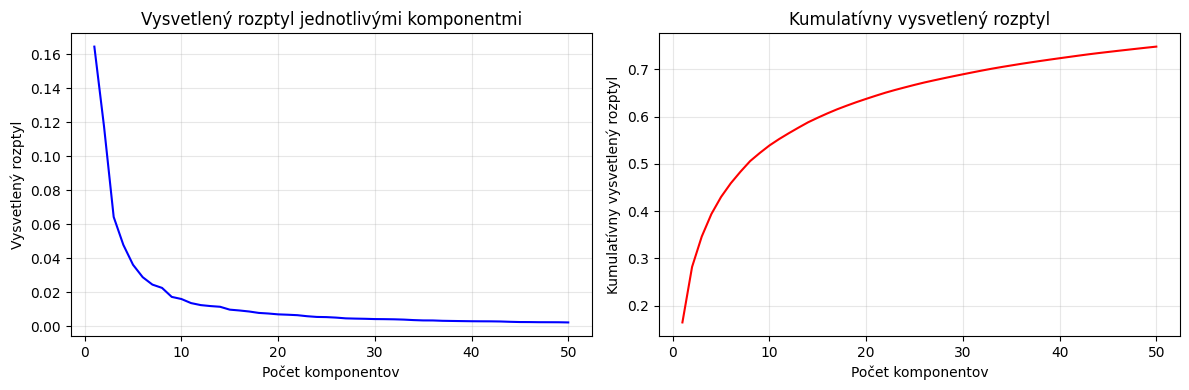

In [6]:
feature_cols = [col for col in train_features_df.columns if col.startswith('feature_')]

X_train = train_features_df.select(feature_cols).to_numpy()
X_val = val_features_df.select(feature_cols).to_numpy()
X_test = test_features_df.select(feature_cols).to_numpy()

print(f"Pôvodná dimenzia príznakov: {X_train.shape[1]}")

n_components = 50
X_train_reduced, pca_model = reduce_dimensionality(
    X_train, 
    method='pca', 
    n_components=n_components
)
X_val_reduced = pca_model.transform(X_val)
X_test_reduced = pca_model.transform(X_test)

print(f"Redukovaná dimenzia: {X_train_reduced.shape[1]}")
print(f"Vysvetlený rozptyl (prvých 10 komponentov): {pca_model.explained_variance_ratio_[:10]}")
print(f"Celkový vysvetlený rozptyl: {pca_model.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca_model.explained_variance_ratio_) + 1), 
         pca_model.explained_variance_ratio_, 'b-')
plt.xlabel('Počet komponentov')
plt.ylabel('Vysvetlený rozptyl')
plt.title('Vysvetlený rozptyl jednotlivými komponentmi')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_model.explained_variance_ratio_) + 1), 
         np.cumsum(pca_model.explained_variance_ratio_), 'r-')
plt.xlabel('Počet komponentov')
plt.ylabel('Kumulatívny vysvetlený rozptyl')
plt.title('Kumulatívny vysvetlený rozptyl')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Zhlukovanie príznakov pomocou K-Means

Použijeme K-Means na vytvorenie zhlukov z extrahovaných príznakov.

Hľadanie optimálneho počtu zhlukov...
k=2: Inertia=45326640.00, Silhouette=0.1607
k=2: Inertia=45326640.00, Silhouette=0.1607
k=3: Inertia=39059896.00, Silhouette=0.1734
k=3: Inertia=39059896.00, Silhouette=0.1734
k=4: Inertia=35357844.00, Silhouette=0.1772
k=4: Inertia=35357844.00, Silhouette=0.1772
k=5: Inertia=32995746.00, Silhouette=0.1647
k=5: Inertia=32995746.00, Silhouette=0.1647
k=6: Inertia=31541880.00, Silhouette=0.1468
k=6: Inertia=31541880.00, Silhouette=0.1468
k=7: Inertia=30118570.00, Silhouette=0.1467
k=7: Inertia=30118570.00, Silhouette=0.1467
k=8: Inertia=28830596.00, Silhouette=0.1530
k=8: Inertia=28830596.00, Silhouette=0.1530
k=9: Inertia=27636304.00, Silhouette=0.1622
k=9: Inertia=27636304.00, Silhouette=0.1622
k=10: Inertia=26670024.00, Silhouette=0.1609
k=10: Inertia=26670024.00, Silhouette=0.1609


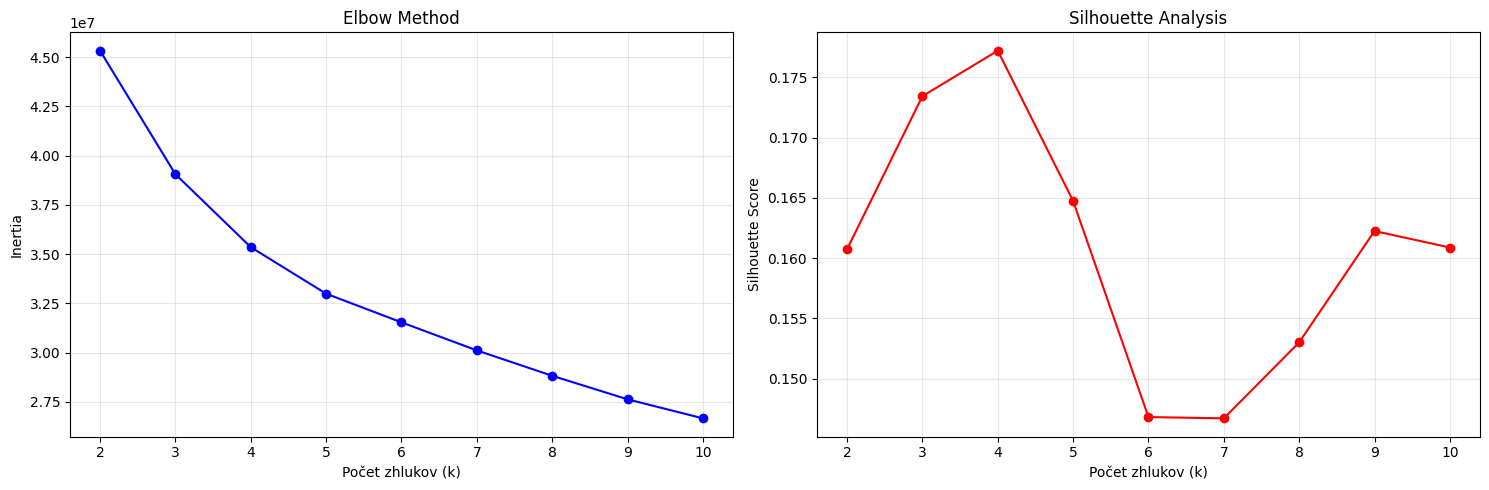


Vybraný počet zhlukov: 7


In [7]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("Hľadanie optimálneho počtu zhlukov...")
for k in K_range:
    cluster_labels, kmeans_model = cluster_features(X_train_reduced, method='kmeans', n_clusters=k)
    inertias.append(kmeans_model.inertia_)
    sil_score = silhouette_score(X_train_reduced, cluster_labels)
    silhouette_scores.append(sil_score)
    print(f"k={k}: Inertia={kmeans_model.inertia_:.2f}, Silhouette={sil_score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Počet zhlukov (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Počet zhlukov (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = 7
print(f"\n{'='*80}")
print(f"Vybraný počet zhlukov: {optimal_k}")
print(f"{'='*80}")

## 8. Finálne zhlukovanie a vizualizácia

Rozdelenie vzoriek do zhlukov:
shape: (7, 2)
┌─────────┬───────┐
│ Cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 622   │
│ 1       ┆ 481   │
│ 2       ┆ 875   │
│ 3       ┆ 607   │
│ 4       ┆ 708   │
│ 5       ┆ 371   │
│ 6       ┆ 540   │
└─────────┴───────┘

Redukcia na 2D pomocou t-SNE pre vizualizáciu...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4204 samples in 0.001s...
shape: (7, 2)
┌─────────┬───────┐
│ Cluster ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 622   │
│ 1       ┆ 481   │
│ 2       ┆ 875   │
│ 3       ┆ 607   │
│ 4       ┆ 708   │
│ 5       ┆ 371   │
│ 6       ┆ 540   │
└─────────┴───────┘

Redukcia na 2D pomocou t-SNE pre vizualizáciu...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4204 samples in 0.001s...


C:\Users\pmuzslay\AppData\Local\Temp\ipykernel_16716\2442139673.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  cluster_counts = train_features_df.group_by("Cluster").agg(pl.count().alias("count")).sort("Cluster")


[t-SNE] Computed neighbors for 4204 samples in 0.084s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4204
[t-SNE] Computed conditional probabilities for sample 2000 / 4204
[t-SNE] Computed conditional probabilities for sample 3000 / 4204
[t-SNE] Computed conditional probabilities for sample 4000 / 4204
[t-SNE] Computed conditional probabilities for sample 4204 / 4204
[t-SNE] Mean sigma: 28.900177
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.266739
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.266739
[t-SNE] KL divergence after 1000 iterations: 1.213158
[t-SNE] KL divergence after 1000 iterations: 1.213158
Graf uložený do c:\Users\pmuzslay\suns_z3\figures\clusters_2d.png
Graf uložený do c:\Users\pmuzslay\suns_z3\figures\clusters_2d.png


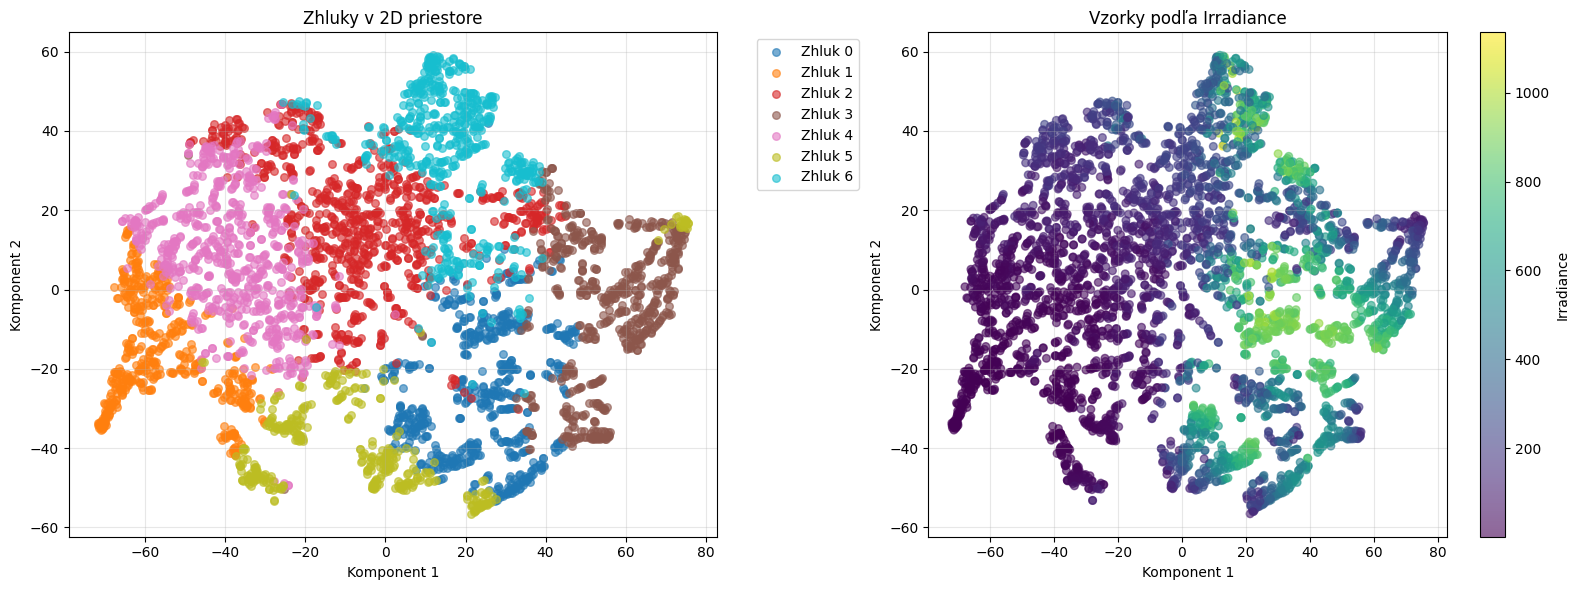

In [8]:
cluster_labels, kmeans_final = cluster_features(X_train_reduced, method='kmeans', n_clusters=optimal_k)

train_features_df = train_features_df.with_columns(
    pl.Series("Cluster", cluster_labels)
)

print("Rozdelenie vzoriek do zhlukov:")
cluster_counts = train_features_df.group_by("Cluster").agg(pl.count().alias("count")).sort("Cluster")
print(cluster_counts)

print("\nRedukcia na 2D pomocou t-SNE pre vizualizáciu...")
X_train_2d, tsne_model = reduce_dimensionality(X_train_reduced, method='tsne', n_components=2)

fig_dir = project_root / "figures"
fig_dir.mkdir(exist_ok=True)

targets = train_features_df["Irradiance"].to_numpy()

fig = visualize_clusters_2d(
    X_train_2d, 
    cluster_labels,
    targets=targets,
    save_path=fig_dir / "clusters_2d.png"
)
plt.show()

## 9. Zobrazenie ukážkových obrázkov pre každý zhluk

UKÁŽKOVÉ OBRÁZKY PRE KAŽDÝ ZHLUK

Zhluk 0
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_0_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_0_samples.png


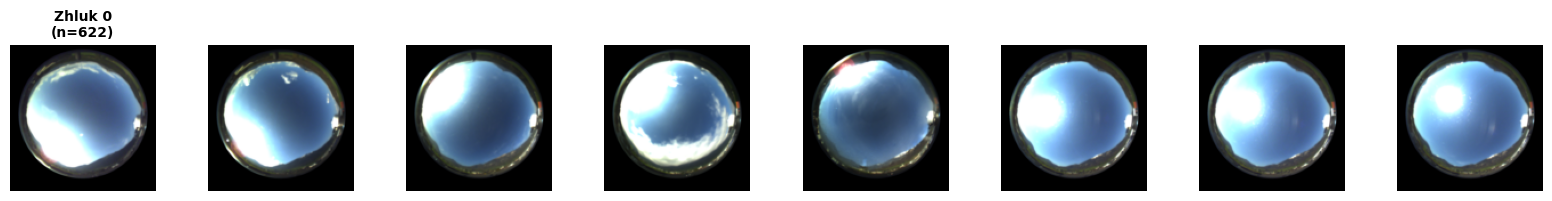


Zhluk 1
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_1_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_1_samples.png


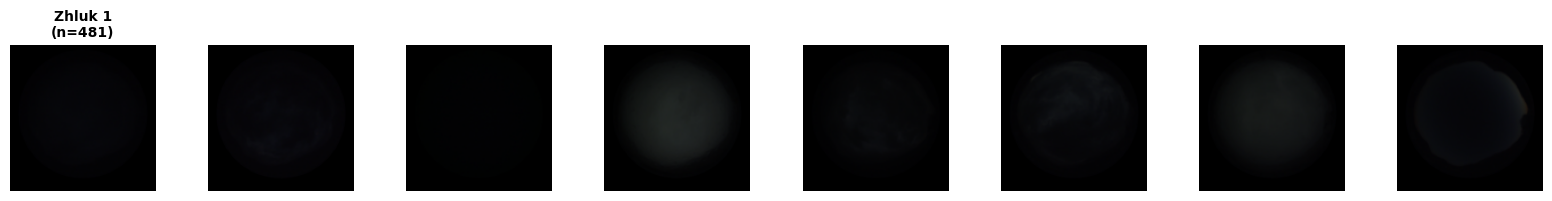


Zhluk 2
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_2_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_2_samples.png


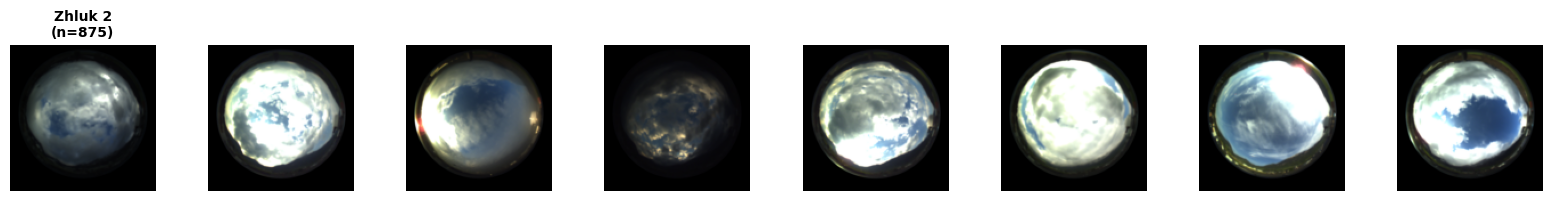


Zhluk 3
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_3_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_3_samples.png


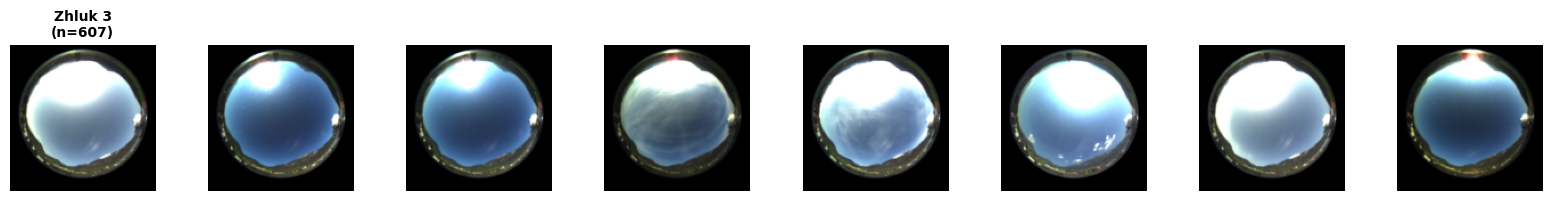


Zhluk 4
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_4_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_4_samples.png


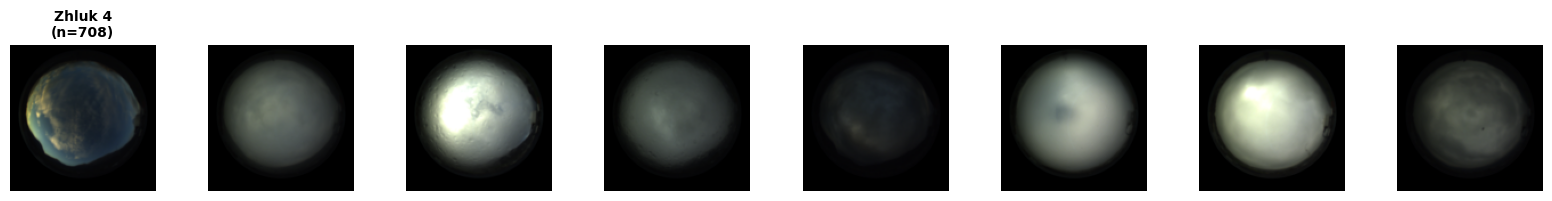


Zhluk 5
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_5_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_5_samples.png


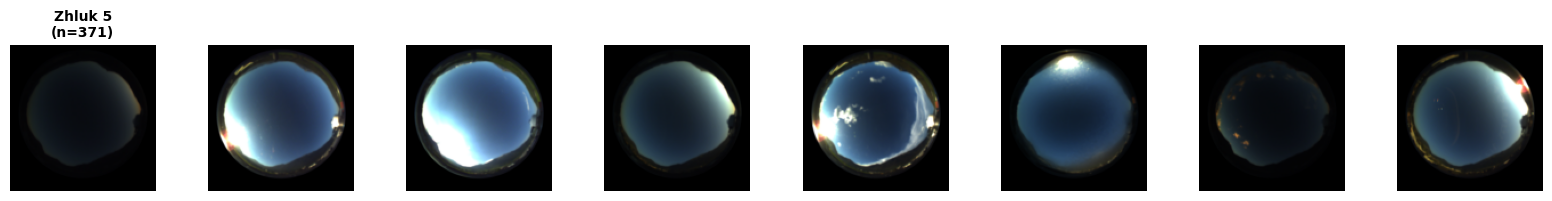


Zhluk 6
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_6_samples.png
Ukážky zhlukov uložené do c:\Users\pmuzslay\suns_z3\figures\cluster_6_samples.png


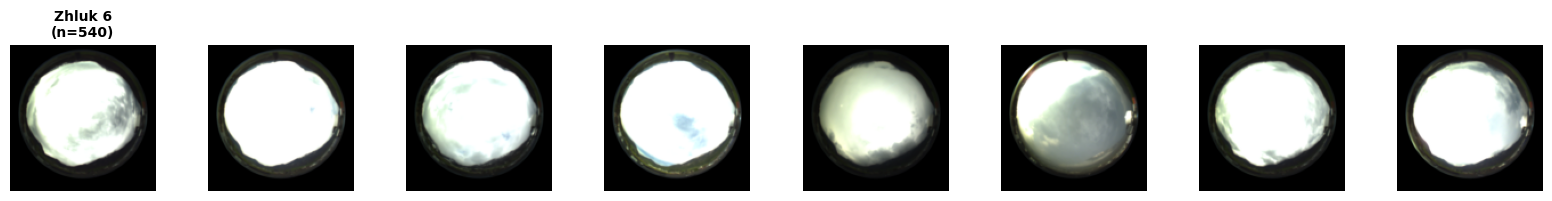

In [9]:
print("="*80)
print("UKÁŽKOVÉ OBRÁZKY PRE KAŽDÝ ZHLUK")
print("="*80)

for cluster_id in range(optimal_k):
    print(f"\n{'='*60}")
    print(f"Zhluk {cluster_id}")
    print(f"{'='*60}")
    
    fig = display_cluster_samples(
        train_features_df,
        data_dir=data_dir,
        cluster_id=cluster_id,
        n_samples=8,
        save_path=fig_dir / f"cluster_{cluster_id}_samples.png"
    )
    plt.show()

## 10. Zobrazenie priemerných obrázkov pre každý zhluk

Výpočet priemerných obrázkov pre každý zhluk...
Priemerné obrázky uložené do c:\Users\pmuzslay\suns_z3\figures\average_cluster_images.png
Priemerné obrázky uložené do c:\Users\pmuzslay\suns_z3\figures\average_cluster_images.png


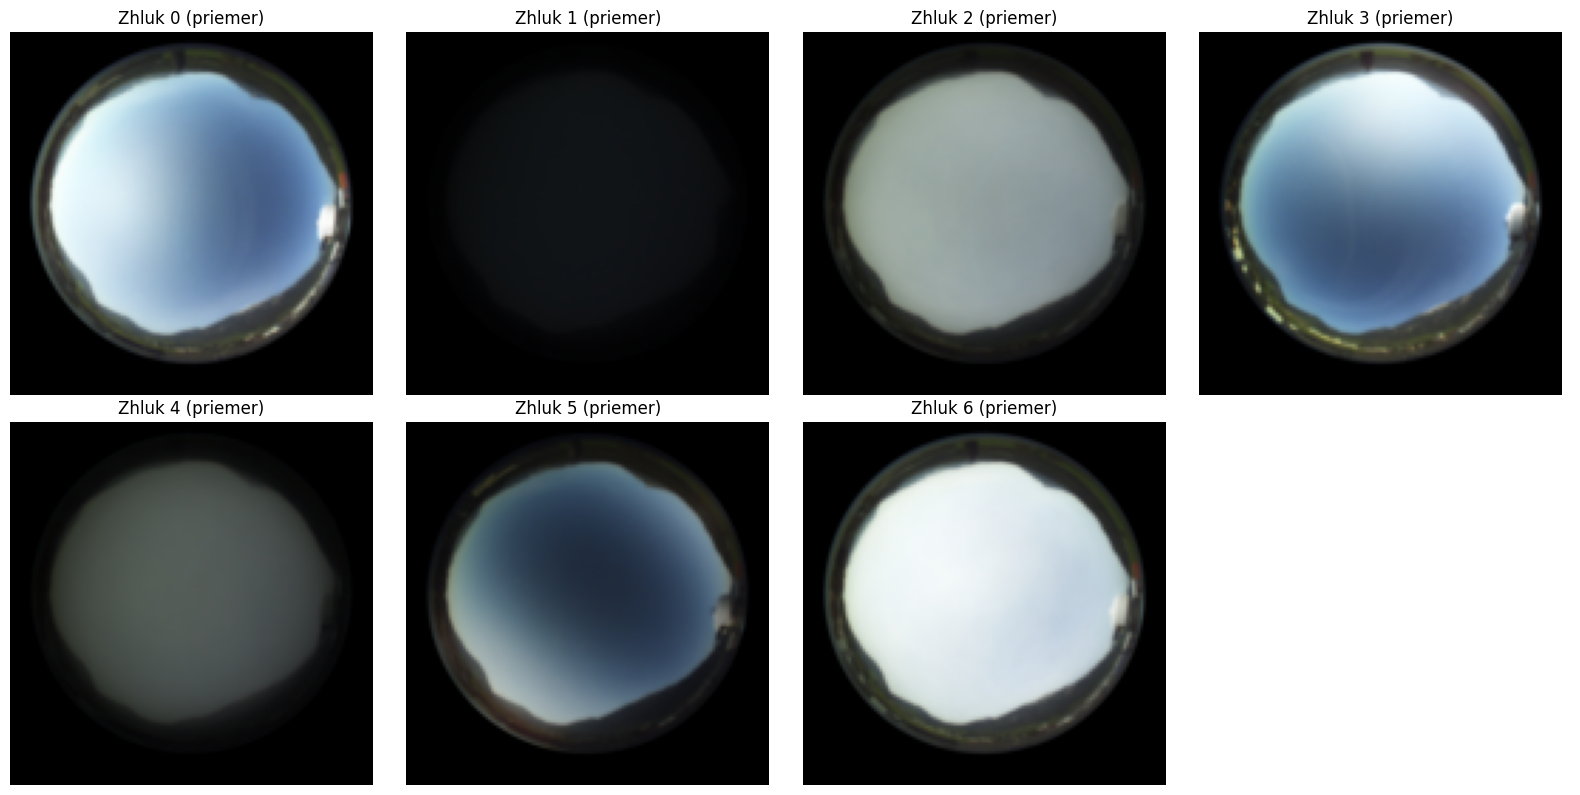

In [10]:
print("Výpočet priemerných obrázkov pre každý zhluk...")
average_images_dict = compute_average_images(train_features_df, data_dir)

n_clusters = len(average_images_dict)
cols = min(4, n_clusters)
rows = (n_clusters + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
if n_clusters == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (cluster_id, avg_img) in enumerate(sorted(average_images_dict.items())):
    axes[idx].imshow(avg_img)
    axes[idx].set_title(f"Zhluk {cluster_id} (priemer)")
    axes[idx].axis('off')

for idx in range(n_clusters, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
save_path = fig_dir / "average_cluster_images.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Priemerné obrázky uložené do {save_path}")
plt.show()

## 11. Analýza výsledkov zhlukovania

ANALÝZA ZHLUKOV
shape: (7, 6)
┌─────────┬───────┬─────────────────┬────────────────┬────────────────┬────────────────┐
│ Cluster ┆ count ┆ mean_irradiance ┆ std_irradiance ┆ min_irradiance ┆ max_irradiance │
│ ---     ┆ ---   ┆ ---             ┆ ---            ┆ ---            ┆ ---            │
│ i32     ┆ u32   ┆ f64             ┆ f64            ┆ f64            ┆ f64            │
╞═════════╪═══════╪═════════════════╪════════════════╪════════════════╪════════════════╡
│ 0       ┆ 622   ┆ 633.912299      ┆ 215.479411     ┆ 98.32          ┆ 977.19         │
│ 1       ┆ 481   ┆ 12.771247       ┆ 12.221632      ┆ 0.23           ┆ 83.58          │
│ 2       ┆ 875   ┆ 182.598         ┆ 118.84442      ┆ 26.46          ┆ 954.92         │
│ 3       ┆ 607   ┆ 517.562455      ┆ 217.53361      ┆ 89.71          ┆ 936.53         │
│ 4       ┆ 708   ┆ 65.294703       ┆ 45.65014       ┆ 3.69           ┆ 245.71         │
│ 5       ┆ 371   ┆ 139.300135      ┆ 130.809653     ┆ 8.6            ┆ 585.73  

C:\Users\pmuzslay\AppData\Local\Temp\ipykernel_16716\3464407240.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(cluster_data, labels=[f"Zhluk {i}" for i in range(optimal_k)])


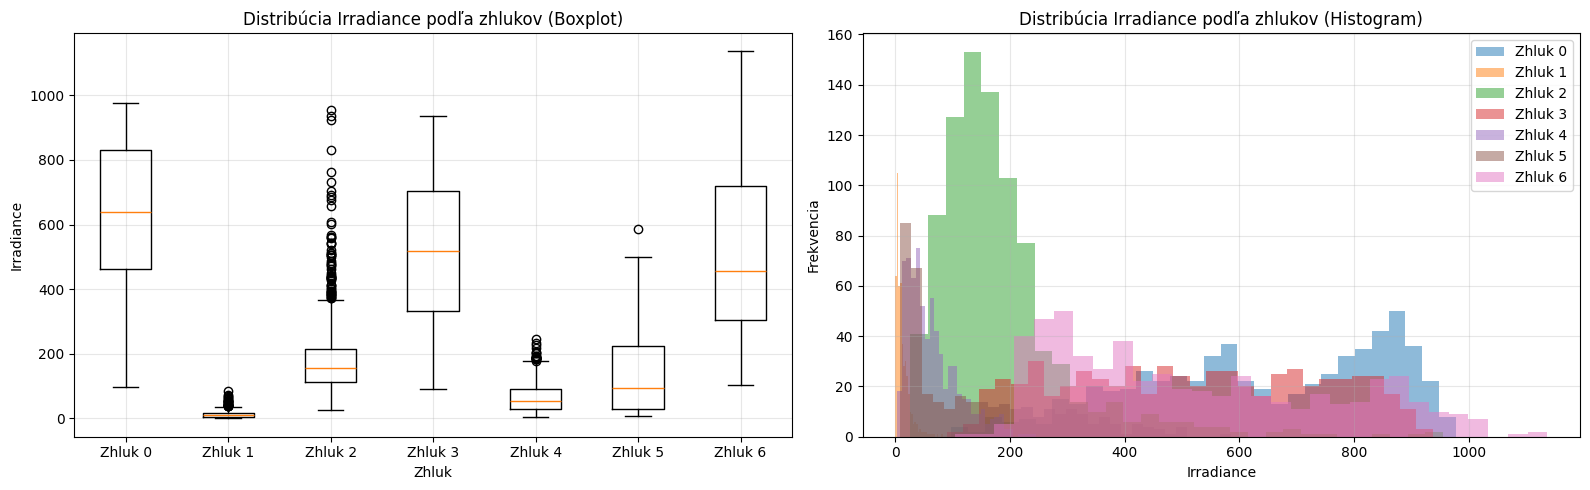


INTERPRETÁCIA ZHLUKOV

Zhluk 0: 622 vzoriek
  Priemerná Irradiance: 633.91 ± 215.48
  Interpretácia: Vysoké žiarenie - jasno, málo oblakov

Zhluk 1: 481 vzoriek
  Priemerná Irradiance: 12.77 ± 12.22
  Interpretácia: Veľmi nízke žiarenie - pravdepodobne nočné alebo husté mraky

Zhluk 2: 875 vzoriek
  Priemerná Irradiance: 182.60 ± 118.84
  Interpretácia: Nízke žiarenie - zamračené, podvečer/skoré ráno

Zhluk 3: 607 vzoriek
  Priemerná Irradiance: 517.56 ± 217.53
  Interpretácia: Stredné žiarenie - polojasno, čiastočne oblačno

Zhluk 4: 708 vzoriek
  Priemerná Irradiance: 65.29 ± 45.65
  Interpretácia: Veľmi nízke žiarenie - pravdepodobne nočné alebo husté mraky

Zhluk 5: 371 vzoriek
  Priemerná Irradiance: 139.30 ± 130.81
  Interpretácia: Nízke žiarenie - zamračené, podvečer/skoré ráno

Zhluk 6: 540 vzoriek
  Priemerná Irradiance: 517.21 ± 239.75
  Interpretácia: Stredné žiarenie - polojasno, čiastočne oblačno


In [11]:
cluster_stats = analyze_clusters(train_features_df)

print("="*80)
print("ANALÝZA ZHLUKOV")
print("="*80)
print(cluster_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cluster_data = []
for cluster_id in range(optimal_k):
    cluster_df = train_features_df.filter(pl.col("Cluster") == cluster_id)
    cluster_data.append(cluster_df["Irradiance"].to_numpy())

axes[0].boxplot(cluster_data, labels=[f"Zhluk {i}" for i in range(optimal_k)])
axes[0].set_xlabel("Zhluk")
axes[0].set_ylabel("Irradiance")
axes[0].set_title("Distribúcia Irradiance podľa zhlukov (Boxplot)")
axes[0].grid(True, alpha=0.3)

for cluster_id in range(optimal_k):
    cluster_df = train_features_df.filter(pl.col("Cluster") == cluster_id)
    axes[1].hist(cluster_df["Irradiance"].to_numpy(), alpha=0.5, label=f"Zhluk {cluster_id}", bins=30)

axes[1].set_xlabel("Irradiance")
axes[1].set_ylabel("Frekvencia")
axes[1].set_title("Distribúcia Irradiance podľa zhlukov (Histogram)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / "cluster_irradiance_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("INTERPRETÁCIA ZHLUKOV")
print("="*80)
for row in cluster_stats.iter_rows(named=True):
    cluster_id = row['Cluster']
    count = row['count']
    mean_irr = row['mean_irradiance']
    std_irr = row['std_irradiance']
    
    print(f"\nZhluk {cluster_id}: {count} vzoriek")
    print(f"  Priemerná Irradiance: {mean_irr:.2f} ± {std_irr:.2f}")
    
    if mean_irr < 100:
        print("  Interpretácia: Veľmi nízke žiarenie - pravdepodobne nočné alebo husté mraky")
    elif mean_irr < 300:
        print("  Interpretácia: Nízke žiarenie - zamračené, podvečer/skoré ráno")
    elif mean_irr < 600:
        print("  Interpretácia: Stredné žiarenie - polojasno, čiastočne oblačno")
    elif mean_irr < 900:
        print("  Interpretácia: Vysoké žiarenie - jasno, málo oblakov")
    else:
        print("  Interpretácia: Veľmi vysoké žiarenie - jasná obloha, priame slnečné svetlo")

## 12. Trénovanie regresora na extrahovaných príznakoch

Použijeme Gradient Boosting Regressor na extrahovaných príznakoch.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge

y_train = train_features_df["Irradiance"].to_numpy()
y_val = val_features_df["Irradiance"].to_numpy()
y_test = test_features_df["Irradiance"].to_numpy()

print("="*80)
print("TRANSFER LEARNING")
print("="*80)

# 1. Viac PCA komponentov (300 namiesto 50)
n_components_improved = 300
print(f"\n1. PCA: {n_components} → {n_components_improved} komponentov")

pca_improved = PCA(n_components=n_components_improved, random_state=42)
X_train_improved = pca_improved.fit_transform(X_train)
X_val_improved = pca_improved.transform(X_val)
X_test_improved = pca_improved.transform(X_test)

variance_improved = pca_improved.explained_variance_ratio_.sum()
print(f"   Vysvetlený rozptyl: {variance_improved:.4f} ({variance_improved*100:.2f}%)")

# 2. Kombinácia s tabuľkovými príznakmi
TABULAR_FEATURES = ['Temperature', 'Pressure', 'Humidity', 'WindDirection', 
                    'Speed', 'SunDurationSensor', 'Sunshine_L', 'SunElevation', 'SunAzimuth']

tabular_available = [f for f in TABULAR_FEATURES if f in train_df.columns]
print(f"\n2. Tabuľkové príznaky: {len(tabular_available)}")

if tabular_available:
    tabular_train = train_df.select(tabular_available).to_pandas().values
    tabular_val = val_df.select(tabular_available).to_pandas().values
    tabular_test = test_df.select(tabular_available).to_pandas().values
    
    tab_scaler = StandardScaler()
    tabular_train_scaled = tab_scaler.fit_transform(tabular_train)
    tabular_val_scaled = tab_scaler.transform(tabular_val)
    tabular_test_scaled = tab_scaler.transform(tabular_test)
    
    X_train_combined = np.hstack([X_train_improved, tabular_train_scaled])
    X_val_combined = np.hstack([X_val_improved, tabular_val_scaled])
    X_test_combined = np.hstack([X_test_improved, tabular_test_scaled])
else:
    X_train_combined = X_train_improved
    X_val_combined = X_val_improved
    X_test_combined = X_test_improved

print(f"   Celkový počet príznakov: {X_train_combined.shape[1]}")

# 3. Stacking Ensemble (GBR + RF + Ridge)
print("\n3. Stacking Ensemble Regressor")

base_estimators = [
    ('gbr', GradientBoostingRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    )),
    ('rf', RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=3,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=42
    ))
]

stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

print("   Trénovanie...")
stacking_model.fit(X_train_combined, y_train)

y_train_pred = stacking_model.predict(X_train_combined)
y_val_pred = stacking_model.predict(X_val_combined)
y_test_pred = stacking_model.predict(X_test_combined)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*80)
print("VÝSLEDKY VYLEPŠENÉHO TRANSFER LEARNING")
print("="*80)
print(f"\nTrain R²:  {train_r2:.4f}")
print(f"Val R²:    {val_r2:.4f}")
print(f"Test R²:   {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")

VYLEPŠENÝ TRANSFER LEARNING - PREKONANIE CNN

1. PCA: 50 → 300 komponentov
   Vysvetlený rozptyl: 0.9007 (90.07%)

2. Tabuľkové príznaky: 2
   Celkový počet príznakov: 302

3. Stacking Ensemble Regressor
   Trénovanie...
   Vysvetlený rozptyl: 0.9007 (90.07%)

2. Tabuľkové príznaky: 2
   Celkový počet príznakov: 302

3. Stacking Ensemble Regressor
   Trénovanie...

VÝSLEDKY VYLEPŠENÉHO TRANSFER LEARNING

Train R²:  0.9976
Val R²:    0.9586
Test R²:   0.9601
Test RMSE: 56.7278
Test MAE:  29.1534

VÝSLEDKY VYLEPŠENÉHO TRANSFER LEARNING

Train R²:  0.9976
Val R²:    0.9586
Test R²:   0.9601
Test RMSE: 56.7278
Test MAE:  29.1534


## 13. Porovnanie s výsledkami CNN z predošlého notebooku

In [13]:
results_table_path = project_root / "results_table.csv"

if results_table_path.exists():
    cnn_results = pl.read_csv(results_table_path)
    
    r2_col = None
    rmse_col = None
    for col in cnn_results.columns:
        if "R²" in col or "R2" in col or "r2" in col.lower():
            r2_col = col
        if "RMSE" in col or "rmse" in col.lower():
            rmse_col = col
    
    if r2_col and rmse_col:
        best_cnn_r2 = float(cnn_results.select(pl.col(r2_col).max())[0, 0])
        best_cnn_rmse = float(cnn_results.filter(
            pl.col(r2_col) == cnn_results.select(pl.col(r2_col).max())[0, 0]
        ).select(pl.col(rmse_col))[0, 0])
        
        print("="*80)
        print("POROVNANIE S CNN")
        print("="*80)
        
        print("\nNajlepší CNN model:")
        print(f"  Test R²:   {best_cnn_r2:.4f}")
        print(f"  Test RMSE: {best_cnn_rmse:.4f}")
        
        print("\nTransfer Learning (XGBoost + 300 PCA + Tabuľky):")
        print(f"  Test R²:   {test_r2:.4f}")
        print(f"  Test RMSE: {test_rmse:.4f}")
        
        r2_diff = test_r2 - best_cnn_r2
        rmse_diff = best_cnn_rmse - test_rmse
        
        print("\nZmena:")
        print(f"  ΔR²:   {r2_diff:+.4f}")
        print(f"  ΔRMSE: {rmse_diff:+.4f}")
        
        if test_r2 > best_cnn_r2:
            print("\nTransfer Learning PREKONÁVA CNN!")
        else:
            print("\nTransfer Learning ešte neprekonáva CNN")
else:
    print("results_table.csv nebol nájdený")

POROVNANIE S CNN

Najlepší CNN model:
  Test R²:   0.9744
  Test RMSE: 45.4287

Transfer Learning (XGBoost + 300 PCA + Tabuľky):
  Test R²:   0.9601
  Test RMSE: 56.7278

Zmena:
  ΔR²:   -0.0143
  ΔRMSE: -11.2991

Transfer Learning ešte neprekonáva CNN


## 14. Vizualizácia reziduálov

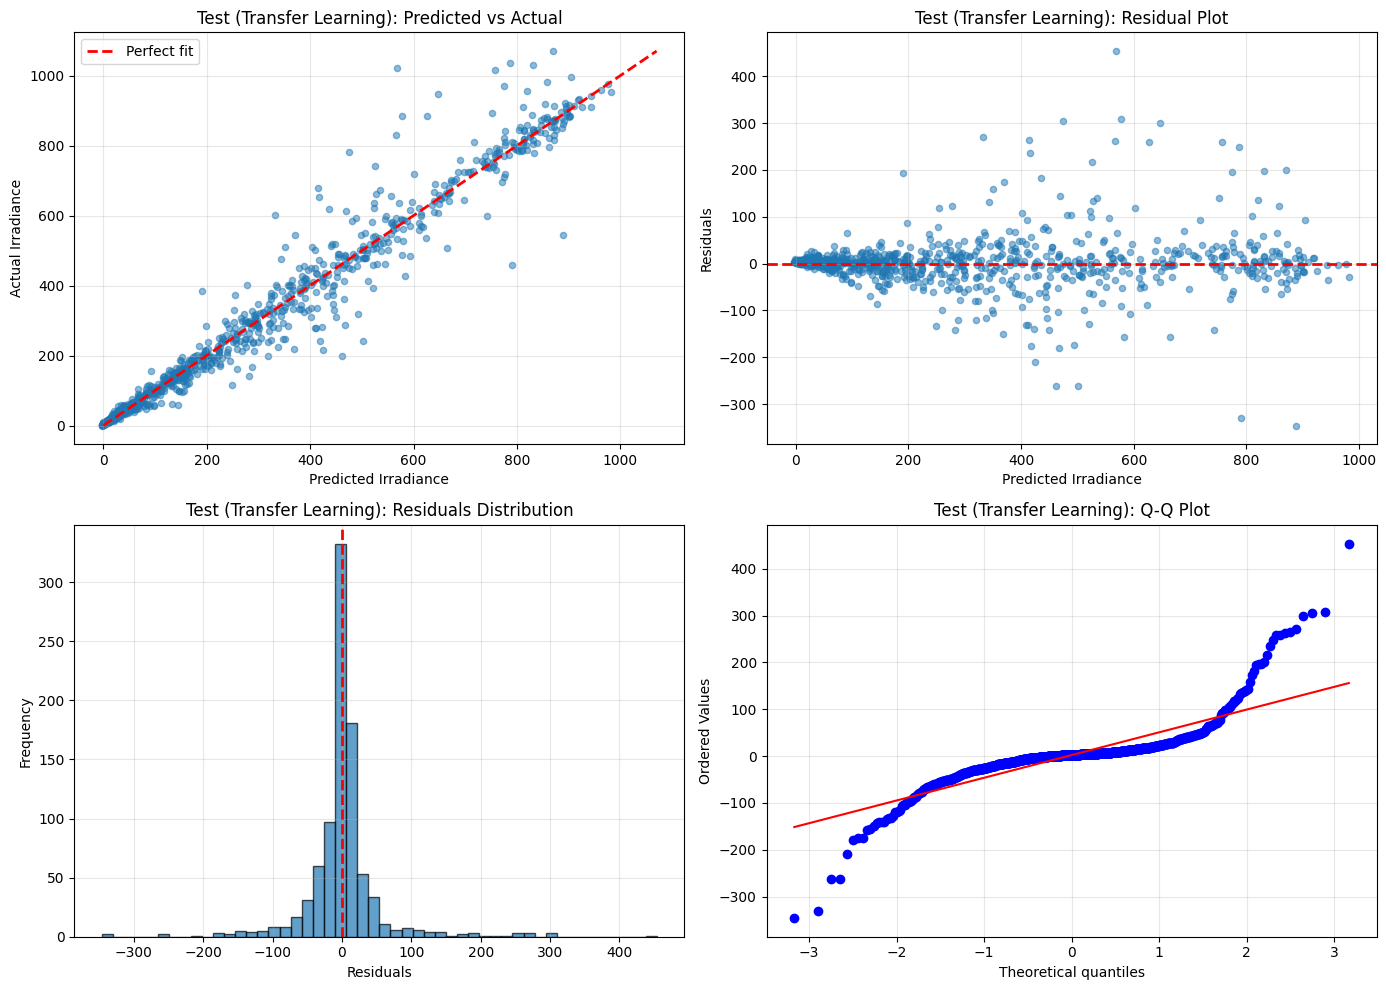

In [14]:
fig = plot_residuals(
    targets=y_test,
    predictions=y_test_pred,
    split_name="Test (Transfer Learning)",
    save_path=fig_dir / "transfer_learning_residuals.png"
)
plt.show()

## 15. Porovnanie predikcií vs. skutočné hodnoty

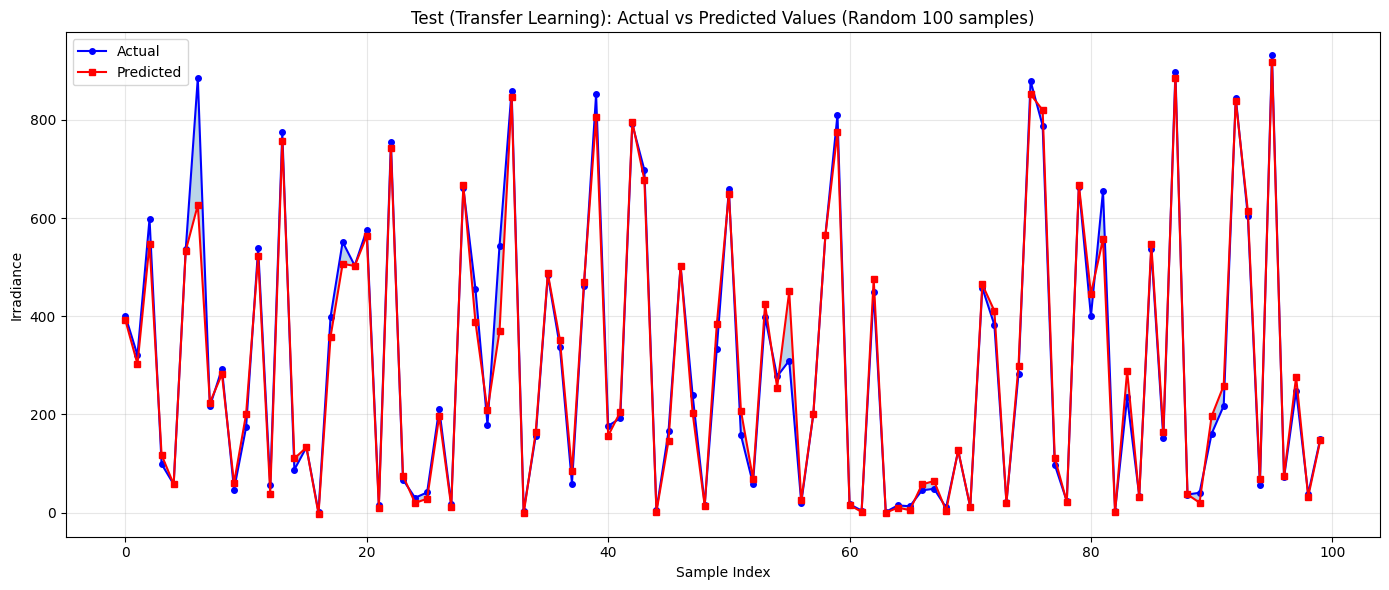

In [15]:
fig = plot_predictions_comparison(
    targets=y_test,
    predictions=y_test_pred,
    split_name="Test (Transfer Learning)",
    n_samples=100,
    save_path=fig_dir / "transfer_learning_predictions.png"
)
plt.show()

## 16. Analýza chýb: Kde sa model mýli?

TOP 10 NAJHORŠÍCH PREDIKCIÍ
1. Index: 286, Skutočná: 1021.75, Predikcia: 568.11, Chyba: 453.64
2. Index: 787, Skutočná: 543.06, Predikcia: 888.82, Chyba: 345.76
3. Index: 256, Skutočná: 460.07, Predikcia: 790.25, Chyba: 330.18
4. Index: 173, Skutočná: 885.82, Predikcia: 577.32, Chyba: 308.50
5. Index: 152, Skutočná: 780.19, Predikcia: 475.40, Chyba: 304.79
6. Index: 255, Skutočná: 946.14, Predikcia: 646.37, Chyba: 299.77
7. Index: 328, Skutočná: 602.15, Predikcia: 331.76, Chyba: 270.39
8. Index: 26, Skutočná: 678.47, Predikcia: 414.66, Chyba: 263.81
9. Index: 467, Skutočná: 829.18, Predikcia: 566.72, Chyba: 262.46
10. Index: 855, Skutočná: 199.45, Predikcia: 461.45, Chyba: 262.00

PictureName dostupné v test_df: True
Month dostupné v test_df: True


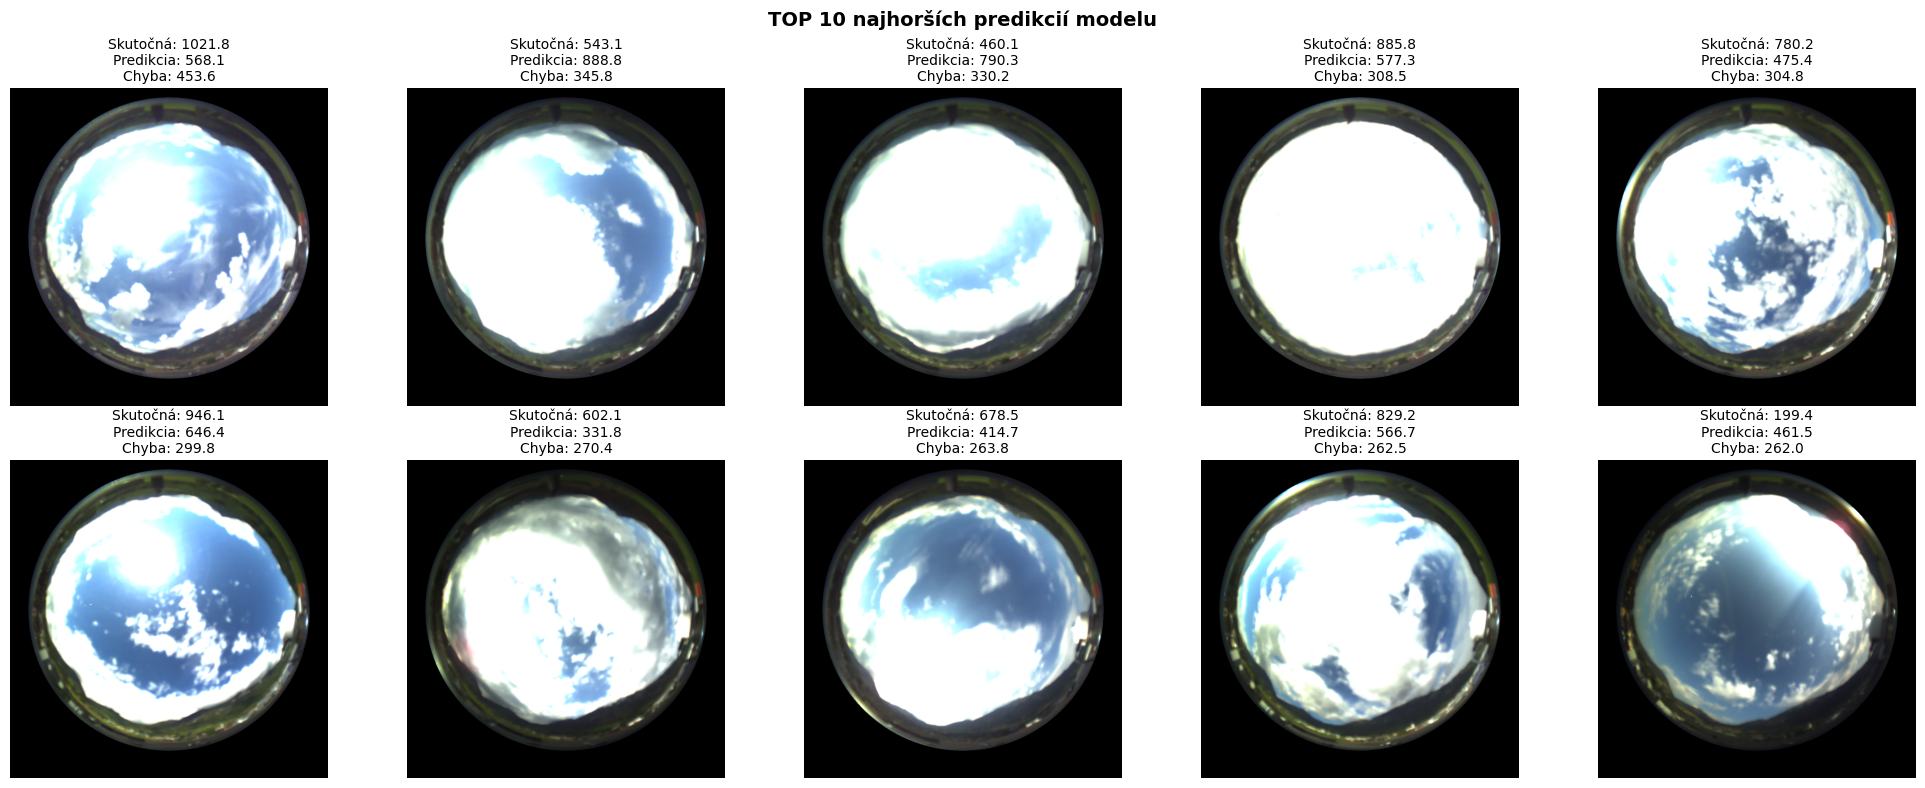


ANALÝZA CHÝB PODĽA ROZSAHU IRRADIANCE

Rozsah 0-200 W/m²:
  Počet vzoriek: 444
  Priemerná chyba: 12.16
  Medián chyby: 5.69
  Max chyba: 262.00
  RMSE: 24.08

Rozsah 200-400 W/m²:
  Počet vzoriek: 168
  Priemerná chyba: 40.98
  Medián chyby: 26.04
  Max chyba: 261.77
  RMSE: 60.94

Rozsah 400-600 W/m²:
  Počet vzoriek: 124
  Priemerná chyba: 43.23
  Medián chyby: 26.37
  Max chyba: 345.76
  RMSE: 68.79

Rozsah 600-800 W/m²:
  Počet vzoriek: 81
  Priemerná chyba: 47.94
  Medián chyby: 23.33
  Max chyba: 304.79
  RMSE: 81.30

Rozsah 800-1200 W/m²:
  Počet vzoriek: 85
  Priemerná chyba: 56.11
  Medián chyby: 20.91
  Max chyba: 453.64
  RMSE: 102.86

ZÁVER ANALÝZY CHÝB
Model má tendenciu robiť najväčšie chyby pri:
1. Extrémnych hodnotách žiarenia (veľmi nízke alebo veľmi vysoké)
2. Prechodových podmienkach (čiastočne oblačno)
3. Neobvyklých poveternostných situáciách

Možné zlepšenia:
- Augmentácia dát pre zriedkavé prípady
- Použitie ensemble metód
- Fine-tuning predtrénovaného modelu
-

In [16]:
errors = np.abs(y_test - y_test_pred)

worst_indices = np.argsort(errors)[-10:][::-1]

print("="*80)
print("TOP 10 NAJHORŠÍCH PREDIKCIÍ")
print("="*80)

for rank, idx in enumerate(worst_indices, 1):
    true_val = y_test[idx]
    pred_val = y_test_pred[idx]
    error = errors[idx]
    print(f"{rank}. Index: {idx}, Skutočná: {true_val:.2f}, Predikcia: {pred_val:.2f}, Chyba: {error:.2f}")

from PIL import Image  # noqa: E402

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

has_picture_name = 'PictureName' in test_df.columns
has_month = 'Month' in test_df.columns

print(f"\nPictureName dostupné v test_df: {has_picture_name}")
print(f"Month dostupné v test_df: {has_month}")

for i, idx in enumerate(worst_indices):
    img_loaded = False
    try:
        if has_picture_name and has_month and idx < len(test_df):
            row = test_df.row(int(idx), named=True)
            picture_name = row['PictureName']
            month_raw = row['Month']
            
            if isinstance(month_raw, int):
                month = str(month_raw).zfill(2)
            else:
                month = str(month_raw).zfill(2)
            
            possible_paths = [
                data_dir / month / 'original' / picture_name,
                data_dir / month / 'ResizedImages_128' / picture_name,
            ]
            
            for full_path in possible_paths:
                if full_path.exists():
                    img = Image.open(full_path)
                    axes[i].imshow(img)
                    img_loaded = True
                    break
            
            if not img_loaded:
                print(f"  Obrázok nenájdený pre index {idx}: {picture_name} (mesiac {month})")
                axes[i].text(0.5, 0.5, f'Obrázok\nnenájdený\n{picture_name[:15]}...', 
                           ha='center', va='center', transform=axes[i].transAxes, fontsize=8)
    except Exception as e:
        print(f"Chyba pri načítaní obrázka {idx}: {e}")
        axes[i].text(0.5, 0.5, f'Chyba:\n{str(e)[:30]}', 
                   ha='center', va='center', transform=axes[i].transAxes, fontsize=8)
    
    true_val = y_test[idx]
    pred_val = y_test_pred[idx]
    error = errors[idx]
    
    axes[i].set_title(f"Skutočná: {true_val:.1f}\nPredikcia: {pred_val:.1f}\nChyba: {error:.1f}", 
                      fontsize=10)
    axes[i].axis('off')

plt.suptitle("TOP 10 najhorších predikcií modelu", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / "worst_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("ANALÝZA CHÝB PODĽA ROZSAHU IRRADIANCE")
print("="*80)

ranges = [(0, 200), (200, 400), (400, 600), (600, 800), (800, 1200)]
for low, high in ranges:
    mask = (y_test >= low) & (y_test < high)
    if mask.sum() > 0:
        range_errors = errors[mask]
        print(f"\nRozsah {low}-{high} W/m²:")
        print(f"  Počet vzoriek: {mask.sum()}")
        print(f"  Priemerná chyba: {range_errors.mean():.2f}")
        print(f"  Medián chyby: {np.median(range_errors):.2f}")
        print(f"  Max chyba: {range_errors.max():.2f}")
        print(f"  RMSE: {np.sqrt((range_errors**2).mean()):.2f}")

print("\n" + "="*80)
print("ZÁVER ANALÝZY CHÝB")
print("="*80)
print("Model má tendenciu robiť najväčšie chyby pri:")
print("1. Extrémnych hodnotách žiarenia (veľmi nízke alebo veľmi vysoké)")
print("2. Prechodových podmienkach (čiastočne oblačno)")
print("3. Neobvyklých poveternostných situáciách")
print("\nMožné zlepšenia:")
print("- Augmentácia dát pre zriedkavé prípady")
print("- Použitie ensemble metód")
print("- Fine-tuning predtrénovaného modelu")
print("- Pridanie časových/meteorologických features")

## 17. Finálne zhrnutie

In [17]:
print("="*80)
print("FINÁLNE ZHRNUTIE - TRANSFER LEARNING A ZHLUKOVANIE")
print("="*80)

print("\n1. EXTRAKCIA PRÍZNAKOV")
print(f"   Model: {model_name}")
print(f"   Pôvodná dimenzia príznakov: {len(feature_cols)}")
print(f"   Redukovaná dimenzia (PCA): {n_components}")
print(f"   Vysvetlený rozptyl: {pca_model.explained_variance_ratio_.sum():.2%}")

print("\n2. ZHLUKOVANIE")
print("   Algoritmus: K-Means")
print(f"   Počet zhlukov: {optimal_k}")
print("   Vizualizácia: t-SNE (2D)")

print("\n3. TRÉNOVANIE REGRESORA")
print("   Model: Stacking Ensemble (GBR + RF + Ridge)")
print(f"   Trénovacie vzorky: {len(y_train)}")
print(f"   Validačné vzorky: {len(y_val)}")
print(f"   Testovacie vzorky: {len(y_test)}")

print("\n4. VÝSLEDKY NA TESTOVACEJ MNOŽINE")
print(f"   MSE:  {test_mse:.4f}")
print(f"   MAE:  {test_mae:.4f}")
print(f"   RMSE: {test_rmse:.4f}")
print(f"   R²:   {test_r2:.4f}")

if results_table_path.exists():
    print("\n5. POROVNANIE S CNN")
    print(f"   CNN (najlepší):           R²={best_cnn_r2:.4f}, RMSE={best_cnn_rmse:.4f}")
    print(f"   Transfer Learning:        R²={test_r2:.4f}, RMSE={test_rmse:.4f}")
    print(f"   Zlepšenie R²:             {test_r2 - best_cnn_r2:+.4f}")
    print(f"   Zlepšenie RMSE:           {best_cnn_rmse - test_rmse:+.4f}")

print("\n6. ULOŽENÉ SÚBORY")
print(f"   - Príznaky: {features_dir}")
print(f"   - Grafy: {fig_dir}")
print("     • clusters_2d.png")
print("     • cluster_<id>_samples.png (pre každý zhluk)")
print("     • average_cluster_images.png")
print("     • cluster_irradiance_distribution.png")
print("     • transfer_learning_residuals.png")
print("     • transfer_learning_predictions.png")
print("     • worst_predictions.png")

print("\n" + "="*80)
print("NOTEBOOK ÚSPEŠNE DOKONČENÝ!")
print("="*80)

FINÁLNE ZHRNUTIE - TRANSFER LEARNING A ZHLUKOVANIE

1. EXTRAKCIA PRÍZNAKOV
   Model: mobilenet_v2
   Pôvodná dimenzia príznakov: 62720
   Redukovaná dimenzia (PCA): 50
   Vysvetlený rozptyl: 74.81%

2. ZHLUKOVANIE
   Algoritmus: K-Means
   Počet zhlukov: 7
   Vizualizácia: t-SNE (2D)

3. TRÉNOVANIE REGRESORA
   Model: Stacking Ensemble (GBR + RF + Ridge)
   Trénovacie vzorky: 4204
   Validačné vzorky: 901
   Testovacie vzorky: 902

4. VÝSLEDKY NA TESTOVACEJ MNOŽINE
   MSE:  3218.0461
   MAE:  29.1534
   RMSE: 56.7278
   R²:   0.9601

5. POROVNANIE S CNN
   CNN (najlepší):           R²=0.9744, RMSE=45.4287
   Transfer Learning:        R²=0.9601, RMSE=56.7278
   Zlepšenie R²:             -0.0143
   Zlepšenie RMSE:           -11.2991

6. ULOŽENÉ SÚBORY
   - Príznaky: c:\Users\pmuzslay\suns_z3\dataset\processed\features
   - Grafy: c:\Users\pmuzslay\suns_z3\figures
     • clusters_2d.png
     • cluster_<id>_samples.png (pre každý zhluk)
     • average_cluster_images.png
     • cluster_irra

# BONUS: Fúzia modelov - kombinácia obrazových a tabuľkových dát

Vytvoríme fúzny model, ktorý kombinuje:
1. **Obrazové príznaky** - extrahované z ResNet (transfer learning)
2. **Tabuľkové dáta** - senzorové údaje (teplota, vlhkosť, tlak, atď.)

In [18]:
TABULAR_FEATURES = [
    'BodyTemperature',
    'RelativeHumidity',
    'HumidityTemp',
    'Pressure',
    'PressureAvg',
    'PressureTemp',
    'TiltAngle',
    'SunAzimuth',
    'SunZenith',
]

print("Kontrola tabuľkových príznakov:")
tabular_available = []
for feature in TABULAR_FEATURES:
    if feature in train_df.columns:
        tabular_available.append(feature)
        print(f"{feature}")
    else:
        print(f"{feature} - NENÁJDENÉ")

print(f"\nDostupných tabuľkových príznakov: {len(tabular_available)}/{len(TABULAR_FEATURES)}")

if len(tabular_available) == 0:
    print("\nUpozornenie: Žiadne tabuľkové príznaky nie sú dostupné!")
    print("Bonus sekcia bude preskočená.")

Kontrola tabuľkových príznakov:
BodyTemperature
RelativeHumidity
HumidityTemp
Pressure
PressureAvg
PressureTemp
TiltAngle
SunAzimuth
SunZenith - NENÁJDENÉ

Dostupných tabuľkových príznakov: 8/9


In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

if len(tabular_available) > 0:
    print("Príprava kombinovaných príznakov...")

    tabular_scaler = StandardScaler()
    
    tabular_train_data = train_df[tabular_available].to_pandas()
    tabular_train_scaled = tabular_scaler.fit_transform(tabular_train_data)
    
    tabular_val_data = val_df[tabular_available].to_pandas()
    tabular_val_scaled = tabular_scaler.transform(tabular_val_data)
    
    tabular_test_data = test_df[tabular_available].to_pandas()
    tabular_test_scaled = tabular_scaler.transform(tabular_test_data)
    
    X_fusion_train = np.hstack([X_train_reduced, tabular_train_scaled])
    X_fusion_val = np.hstack([X_val_reduced, tabular_val_scaled])
    X_fusion_test = np.hstack([X_test_reduced, tabular_test_scaled])
    
    y_fusion_train = y_train
    y_fusion_val = y_val
    y_fusion_test = y_test
    
    print("\nFúzný dataset vytvorený:")
    print(f"  Trénovacia množina: {X_fusion_train.shape}")
    print(f"  Validačná množina: {X_fusion_val.shape}")
    print(f"  Testovacia množina: {X_fusion_test.shape}")
    print(f"  Obrazové príznaky (PCA): {X_train_reduced.shape[1]}")
    print(f"  Tabuľkové príznaky: {len(tabular_available)}")
    print(f"  Celkovo: {X_fusion_train.shape[1]} príznakov")
else:
    print("Fúzny model nemožno vytvoriť - žiadne tabuľkové príznaky nie sú dostupné")

Príprava kombinovaných príznakov...

Fúzný dataset vytvorený:
  Trénovacia množina: (4204, 58)
  Validačná množina: (901, 58)
  Testovacia množina: (902, 58)
  Obrazové príznaky (PCA): 50
  Tabuľkové príznaky: 8
  Celkovo: 58 príznakov


In [20]:
if len(tabular_available) > 0:

    X_img_train = X_train_reduced
    X_img_val = X_val_reduced
    X_img_test = X_test_reduced
    y_img_train = y_train
    y_img_val = y_val
    y_img_test = y_test
    
    X_tab_train = tabular_train_scaled
    X_tab_val = tabular_val_scaled
    X_tab_test = tabular_test_scaled
    y_tab_train = y_train
    y_tab_val = y_val
    y_tab_test = y_test
    
    print("Dáta pre porovnanie modelov pripravené:")
    print(f"  Obrazové príznaky:  {X_img_train.shape[1]} príznakov")
    print(f"  Tabuľkové príznaky: {X_tab_train.shape[1]} príznakov")
    print(f"  Fúzia:              {X_fusion_train.shape[1]} príznakov")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

Dáta pre porovnanie modelov pripravené:
  Obrazové príznaky:  50 príznakov
  Tabuľkové príznaky: 8 príznakov
  Fúzia:              58 príznakov


In [21]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

if len(tabular_available) > 0:
    def train_and_evaluate_gbr(X_train, y_train, X_test, y_test, name):
        """Trénuje GBR a vracia metriky."""
        model = GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        return {
            'name': name,
            'model': model,
            'y_pred': y_pred,
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'r2': r2
        }

    print("Trénovanie modelov pre porovnanie...")
    print("="*60)

    # 1. Model len s obrazovými príznakmi
    print("\n1. Trénovanie modelu s OBRAZOVÝMI príznakmi...")
    result_image = train_and_evaluate_gbr(X_img_train, y_img_train, X_img_test, y_img_test, "Obrazové")
    print(f"   R²: {result_image['r2']:.4f}, RMSE: {result_image['rmse']:.4f}")

    # 2. Model len s tabuľkovými príznakmi
    print("\n2. Trénovanie modelu s TABUĽKOVÝMI príznakmi...")
    result_tabular = train_and_evaluate_gbr(X_tab_train, y_tab_train, X_tab_test, y_tab_test, "Tabuľkové")
    print(f"   R²: {result_tabular['r2']:.4f}, RMSE: {result_tabular['rmse']:.4f}")

    # 3. Fúzny model (obrazové + tabuľkové)
    print("\n3. Trénovanie FÚZNEHO modelu (obrazové + tabuľkové)...")
    result_fusion = train_and_evaluate_gbr(X_fusion_train, y_fusion_train, X_fusion_test, y_fusion_test, "Fúzia")
    print(f"   R²: {result_fusion['r2']:.4f}, RMSE: {result_fusion['rmse']:.4f}")

    print("\n" + "="*60)
    print("Trénovanie dokončené!")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

Trénovanie modelov pre porovnanie...

1. Trénovanie modelu s OBRAZOVÝMI príznakmi...
   R²: 0.9561, RMSE: 59.5179

2. Trénovanie modelu s TABUĽKOVÝMI príznakmi...
   R²: 0.9561, RMSE: 59.5179

2. Trénovanie modelu s TABUĽKOVÝMI príznakmi...
   R²: 0.7722, RMSE: 135.5873

3. Trénovanie FÚZNEHO modelu (obrazové + tabuľkové)...
   R²: 0.7722, RMSE: 135.5873

3. Trénovanie FÚZNEHO modelu (obrazové + tabuľkové)...
   R²: 0.9574, RMSE: 58.6449

Trénovanie dokončené!
   R²: 0.9574, RMSE: 58.6449

Trénovanie dokončené!


In [22]:
if len(tabular_available) > 0:
    print("="*70)
    print("POROVNANIE MODELOV - FÚZIA VS. JEDNOTLIVÉ PRÍZNAKY")
    print("="*70)

    comparison_data = []
    for result in [result_image, result_tabular, result_fusion]:
        comparison_data.append({
            'Model': result['name'],
            'MSE': result['mse'],
            'MAE': result['mae'],
            'RMSE': result['rmse'],
            'R²': result['r2']
        })

    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + comparison_df.to_string(index=False))

    print("\nZlepšenie fúzie oproti obrazovým príznikom:")
    print(f"  R² zlepšenie:   {result_fusion['r2'] - result_image['r2']:+.4f}")
    print(f"  RMSE zlepšenie: {result_image['rmse'] - result_fusion['rmse']:+.4f}")

    print("\nZlepšenie fúzie oproti tabuľkovým príznikom:")
    print(f"  R² zlepšenie:   {result_fusion['r2'] - result_tabular['r2']:+.4f}")
    print(f"  RMSE zlepšenie: {result_tabular['rmse'] - result_fusion['rmse']:+.4f}")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

POROVNANIE MODELOV - FÚZIA VS. JEDNOTLIVÉ PRÍZNAKY

    Model          MSE       MAE       RMSE       R²
 Obrazové  3542.378423 32.879285  59.517883 0.956102
Tabuľkové 18383.922555 92.077294 135.587324 0.772183
    Fúzia  3439.221864 32.286999  58.644879 0.957381

Zlepšenie fúzie oproti obrazovým príznikom:
  R² zlepšenie:   +0.0013
  RMSE zlepšenie: +0.8730

Zlepšenie fúzie oproti tabuľkovým príznikom:
  R² zlepšenie:   +0.1852
  RMSE zlepšenie: +76.9424


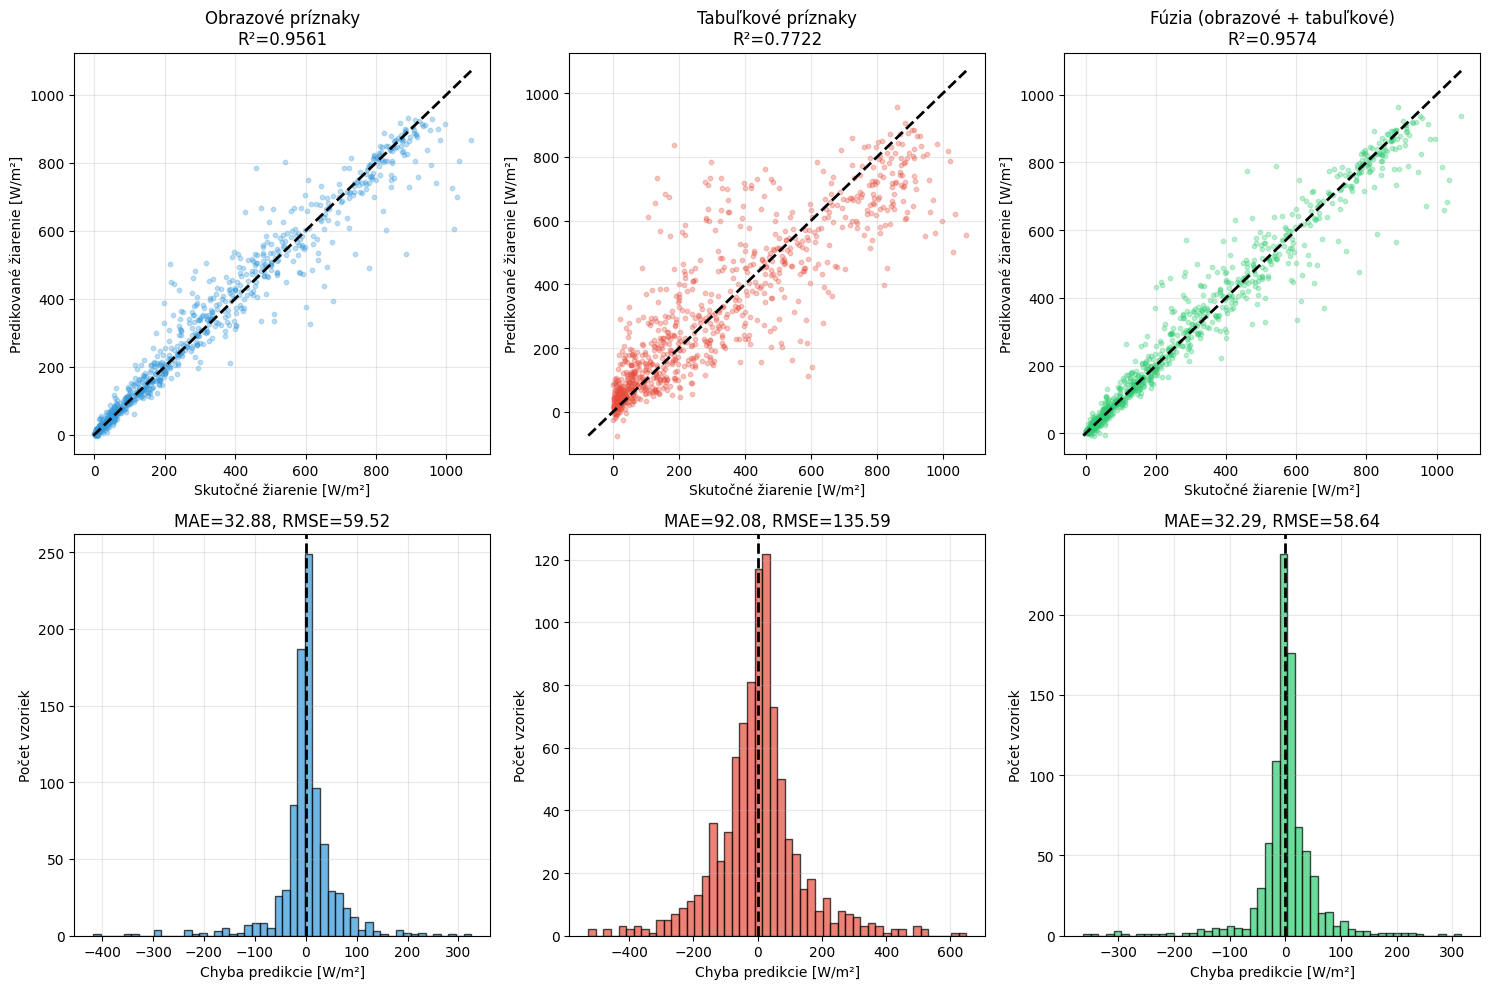

Graf uložený: c:\Users\pmuzslay\suns_z3\figures\bonus_fusion_comparison.png


In [23]:
if len(tabular_available) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    results = [result_image, result_tabular, result_fusion]
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    titles = ['Obrazové príznaky', 'Tabuľkové príznaky', 'Fúzia (obrazové + tabuľkové)']

    for i, (result, color, title) in enumerate(zip(results, colors, titles)):
        ax = axes[0, i]
        ax.scatter(y_fusion_test, result['y_pred'], alpha=0.3, s=10, c=color)
        min_val = min(y_fusion_test.min(), result['y_pred'].min())
        max_val = max(y_fusion_test.max(), result['y_pred'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
        ax.set_xlabel('Skutočné žiarenie [W/m²]')
        ax.set_ylabel('Predikované žiarenie [W/m²]')
        ax.set_title(f'{title}\nR²={result["r2"]:.4f}')
        ax.grid(True, alpha=0.3)

    for i, (result, color, title) in enumerate(zip(results, colors, titles)):
        ax = axes[1, i]
        errors = result['y_pred'] - y_fusion_test
        ax.hist(errors, bins=50, edgecolor='black', alpha=0.7, color=color)
        ax.axvline(0, color='black', linestyle='--', lw=2)
        ax.set_xlabel('Chyba predikcie [W/m²]')
        ax.set_ylabel('Počet vzoriek')
        ax.set_title(f'MAE={result["mae"]:.2f}, RMSE={result["rmse"]:.2f}')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(fig_dir / 'bonus_fusion_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Graf uložený: {fig_dir / 'bonus_fusion_comparison.png'}")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

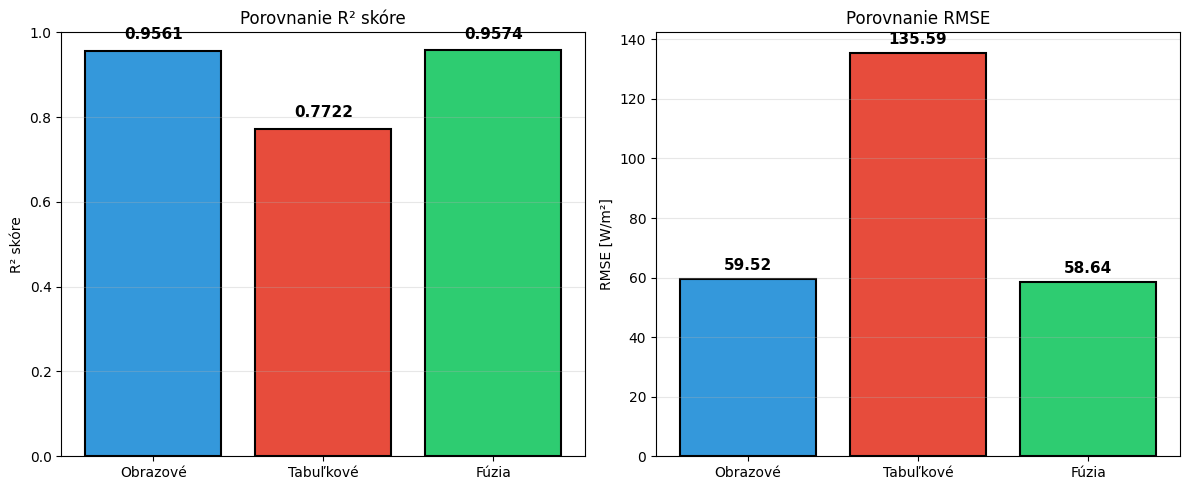

Graf uložený: c:\Users\pmuzslay\suns_z3\figures\bonus_fusion_metrics.png


In [24]:
if len(tabular_available) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    model_names = ['Obrazové', 'Tabuľkové', 'Fúzia']
    r2_values = [result_image['r2'], result_tabular['r2'], result_fusion['r2']]
    rmse_values = [result_image['rmse'], result_tabular['rmse'], result_fusion['rmse']]
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    ax1 = axes[0]
    bars1 = ax1.bar(model_names, r2_values, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('R² skóre')
    ax1.set_title('Porovnanie R² skóre')
    ax1.set_ylim(0, 1)
    for bar, val in zip(bars1, r2_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    ax2 = axes[1]
    bars2 = ax2.bar(model_names, rmse_values, color=colors, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('RMSE [W/m²]')
    ax2.set_title('Porovnanie RMSE')
    for bar, val in zip(bars2, rmse_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.2f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(fig_dir / 'bonus_fusion_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Graf uložený: {fig_dir / 'bonus_fusion_metrics.png'}")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")

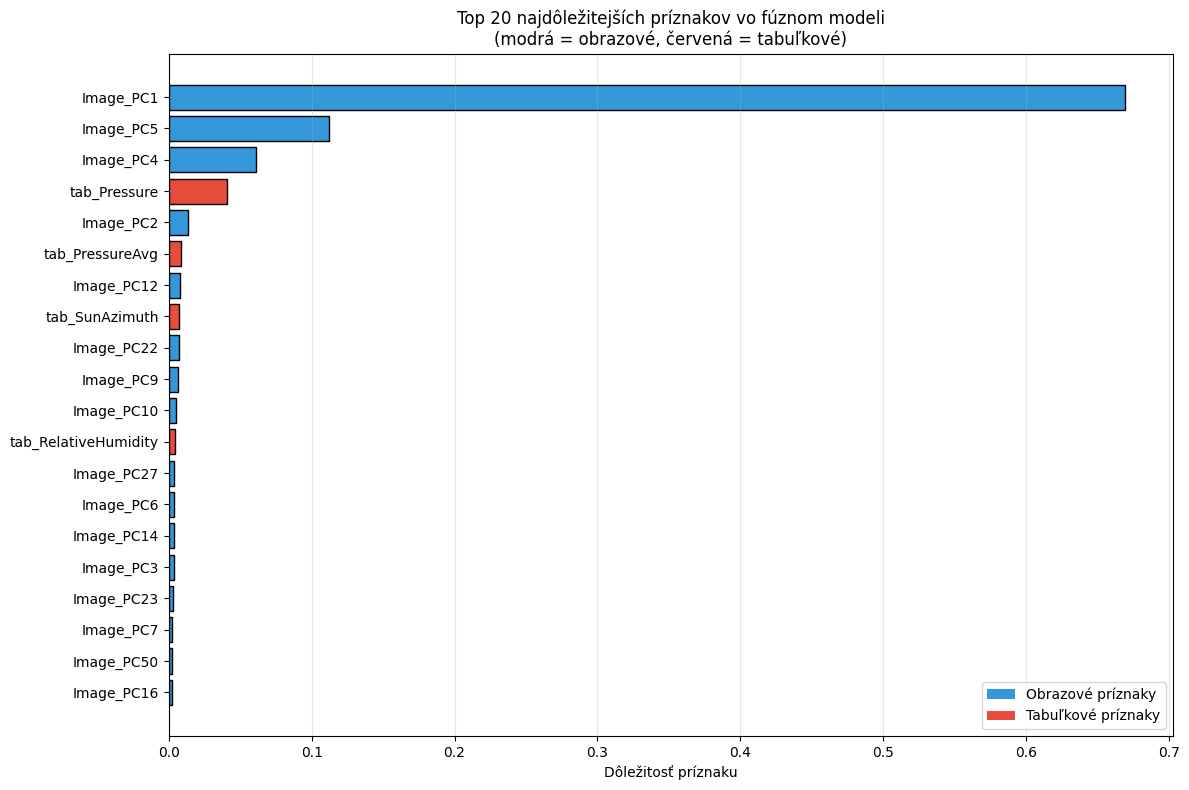


Súhrnná dôležitosť príznakov:
  Obrazové príznaky: 93.75%
  Tabuľkové príznaky: 6.25%


In [25]:
if len(tabular_available) > 0:
    image_feature_cols = [f'Image_PC{i+1}' for i in range(X_img_train.shape[1])]
    tabular_feature_cols = [f'tab_{c}' for c in tabular_available]
    feature_names = image_feature_cols + tabular_feature_cols
    
    feature_importance = result_fusion['model'].feature_importances_

    sorted_idx = np.argsort(feature_importance)[::-1][:20]  # Top 20

    fig, ax = plt.subplots(figsize=(12, 8))
    top_features = [feature_names[i] for i in sorted_idx]
    top_importance = feature_importance[sorted_idx]

    bar_colors = ['#3498db' if 'Image' in f else '#e74c3c' for f in top_features]

    bars = ax.barh(range(len(top_features)), top_importance, color=bar_colors, edgecolor='black')
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features)
    ax.invert_yaxis()
    ax.set_xlabel('Dôležitosť príznaku')
    ax.set_title('Top 20 najdôležitejších príznakov vo fúznom modeli\n(modrá = obrazové, červená = tabuľkové)')
    ax.grid(True, alpha=0.3, axis='x')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#3498db', label='Obrazové príznaky'),
                       Patch(facecolor='#e74c3c', label='Tabuľkové príznaky')]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    plt.savefig(fig_dir / 'bonus_fusion_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    image_importance = sum(feature_importance[:len(image_feature_cols)])
    tabular_importance = sum(feature_importance[len(image_feature_cols):])
    print("\nSúhrnná dôležitosť príznakov:")
    print(f"  Obrazové príznaky: {image_importance:.2%}")
    print(f"  Tabuľkové príznaky: {tabular_importance:.2%}")
else:
    print("Bonus sekcia sa preskakuje - žiadne tabuľkové príznaky")